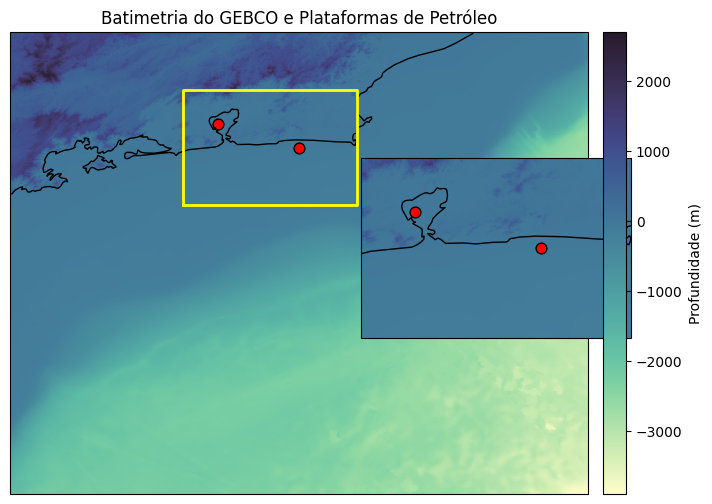

In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xarray as xr
import numpy as np
import cmocean

# === 1. Abrir dados GEBCO ===
file_path = "/mnt/c/Users/henri/OneDrive - atmosmarine.com/GEBCO/gebco_2024/gebco_2024.nc"  # Substitua pelo caminho correto
ds_gebco = xr.open_dataset(file_path)
ds_gebco = ds_gebco.sel(lat=slice(-26, -22), lon=slice(-45.0, -40.0))

lon = ds_gebco.lon.values
lat = ds_gebco.lat.values
bathymetry = ds_gebco.elevation.values  # Supondo que os dados estão negativos (m)

# === 2. Definir coordenadas das plataformas ===
platforms = {
    "Plataforma 1": (-42.5, -23.0),
    "Plataforma 2": (-43.2, -22.8)
}
platform_lons, platform_lats = zip(*platforms.values())

# === 3. Criar a figura e subplots ===
fig, ax_main = plt.subplots(figsize=(10, 6), subplot_kw={'projection': ccrs.PlateCarree()})
ax_zoom = fig.add_axes([0.62, 0.37, 0.3, 0.3], projection=ccrs.PlateCarree())  # Subplot de zoom

# === 4. Plot do mapa grande ===
c = ax_main.pcolormesh(lon, lat, bathymetry, cmap=cmocean.cm.deep, shading='auto', transform=ccrs.PlateCarree())
ax_main.scatter(platform_lons, platform_lats, color='red', edgecolor='black', s=60, label="Plataformas")

# Adiciona feições do mapa
ax_main.coastlines(resolution='10m', color='black', linewidth=1)
ax_main.add_feature(cfeature.LAND, color='lightgray')
ax_main.add_feature(cfeature.BORDERS, linestyle=':')
ax_main.set_title("Batimetria do GEBCO e Plataformas de Petróleo")

# Barra de cores
cbar = fig.colorbar(c, ax=ax_main, orientation='vertical', fraction=0.03, pad=0.02)
cbar.set_label("Profundidade (m)")

# === 5. Plot do mapa de zoom ===
zoom_extent = [-43.5, -42.0, -23.5, -22.5]  # Defina os limites do zoom
ax_zoom.set_extent(zoom_extent, crs=ccrs.PlateCarree())
ax_zoom.pcolormesh(lon, lat, bathymetry, cmap=cmocean.cm.deep, shading='auto', transform=ccrs.PlateCarree())
ax_zoom.scatter(platform_lons, platform_lats, color='red', edgecolor='black', s=60)

# Adiciona feições no zoom
ax_zoom.coastlines(resolution='10m', color='black', linewidth=1)
ax_zoom.add_feature(cfeature.LAND, color='lightgray')

# Desenha um retângulo no mapa grande para indicar a área do zoom
ax_main.plot([zoom_extent[0], zoom_extent[1], zoom_extent[1], zoom_extent[0], zoom_extent[0]], 
             [zoom_extent[2], zoom_extent[2], zoom_extent[3], zoom_extent[3], zoom_extent[2]], 
             color="yellow", linewidth=2, transform=ccrs.PlateCarree())

plt.show()
